<a href="https://colab.research.google.com/github/ayatayoub20/Time-Series-Analysis/blob/main/Gridsearch_SARIMA_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 27.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.api as tsa
import pmdarima as pm

from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs, nsdiffs

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

plt.rcParams["figure.figsize"] = (12, 4)

In [21]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [22]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [24]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [25]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

In [4]:
url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQN3Ksa9szQuO4G1-msXWAp17KtVHQCBnuEieu_auu1wSiBf3-krHusIx5VBMkihxj-KZLBosDIGEyR/pub?output=csv"

df = pd.read_csv(url)
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0,255517.0,...,741586.0,745686.0,750578.0,756734.0,762321.0,768797.0,773944.0,777692.0,779960.0,781622.0
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0,234401.0,...,924019.0,928991.0,937936.0,953874.0,973168.0,990391.0,992337.0,992630.0,978196.0,966595.0
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0,109079.0,...,245783.0,248718.0,252080.0,256435.0,261101.0,265558.0,268901.0,271059.0,272400.0,272639.0
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0,166536.0,...,302821.0,305104.0,306404.0,308303.0,309649.0,312487.0,314663.0,315910.0,315587.0,315429.0
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,114794.0,114975.0,...,269323.0,274032.0,278464.0,284127.0,289739.0,294776.0,297727.0,298796.0,299124.0,298951.0


In [5]:
ny = df[df["RegionName"] == "New York"].copy()

ny

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0,255517.0,...,741586.0,745686.0,750578.0,756734.0,762321.0,768797.0,773944.0,777692.0,779960.0,781622.0


In [6]:
date_columns = df.columns[8:]

ts = ny[date_columns].T
ts.head()

,0
2000-01-31,253690.0
2000-02-29,255517.0
2000-03-31,257207.0
2000-04-30,260310.0
2000-05-31,263204.0


In [7]:
ts.columns = ["Home Value"]

ts.index = pd.to_datetime(ts.index)

ts.head()

,Home Value
2000-01-31,253690.0
2000-02-29,255517.0
2000-03-31,257207.0
2000-04-30,260310.0
2000-05-31,263204.0


In [8]:
ts = ts["Home Value"]

ts = ts.asfreq("ME")

ts.head()

,Home Value
2000-01-31,253690.0
2000-02-29,255517.0
2000-03-31,257207.0
2000-04-30,260310.0
2000-05-31,263204.0


In [9]:
ts = ts.loc["2018":]

ts.head()

,Home Value
2018-01-31,656700.0
2018-02-28,661012.0
2018-03-31,665672.0
2018-04-30,669989.0
2018-05-31,673514.0


In [10]:
print("Start:", ts.index.min())
print("End:", ts.index.max())
print("Number of observations:", len(ts))

Start: 2018-01-31 00:00:00
End: 2022-09-30 00:00:00
Number of observations: 57


In [12]:
ts.head()


,Home Value
2018-01-31,656700.0
2018-02-28,661012.0
2018-03-31,665672.0
2018-04-30,669989.0
2018-05-31,673514.0


In [13]:
ts.tail()

,Home Value
2022-05-31,768797.0
2022-06-30,773944.0
2022-07-31,777692.0
2022-08-31,779960.0
2022-09-30,781622.0


In [14]:
ts.isna().sum()

np.int64(0)

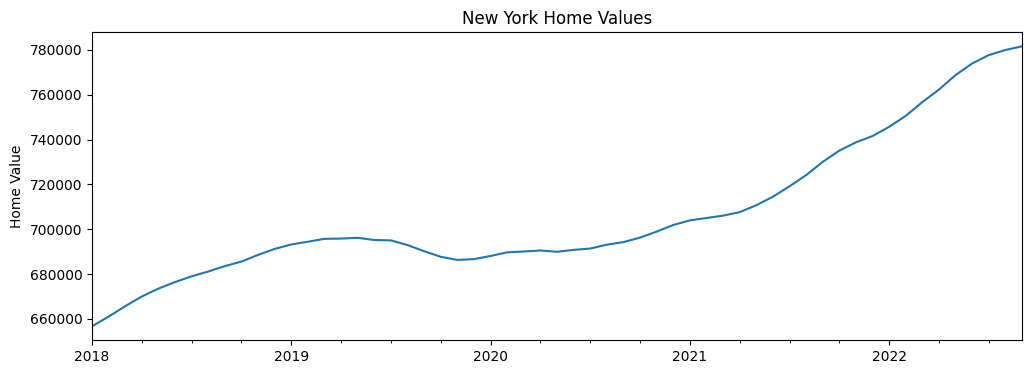

In [15]:
ts.plot(figsize=(12,4))

plt.title("New York Home Values")

plt.ylabel("Home Value")

plt.show()

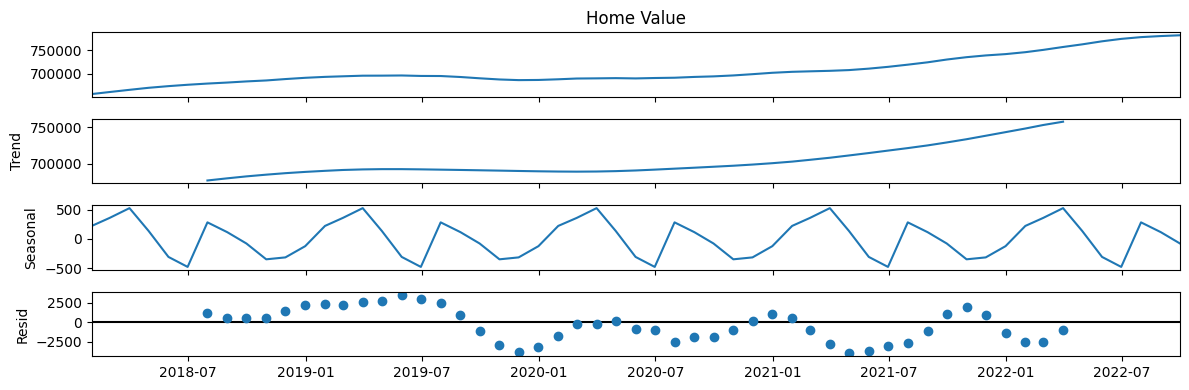

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(
    ts,
    model="additive",
    period=12
)

decomp.plot();

plt.show()

In [17]:
seasonal_delta = (
    decomp.seasonal.max()
    -
    decomp.seasonal.min()
)

seasonal_delta

1006.1319444442925

In [18]:
ts_delta = ts.max() - ts.min()

ts_delta

124922.0

In [19]:
seasonality_percent = (
    seasonal_delta / ts_delta
) * 100

print(seasonality_percent)

0.8054081302286967


In [26]:
get_adfuller_results(ts, label="Raw Data")

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Raw Data,0.407572,4,52,0.981776,0.05,False


In [27]:
d = ndiffs(ts)
print("d =", d)

d = 2


In [28]:
D = nsdiffs(ts, m=12)
print("D =", D)

D = 0


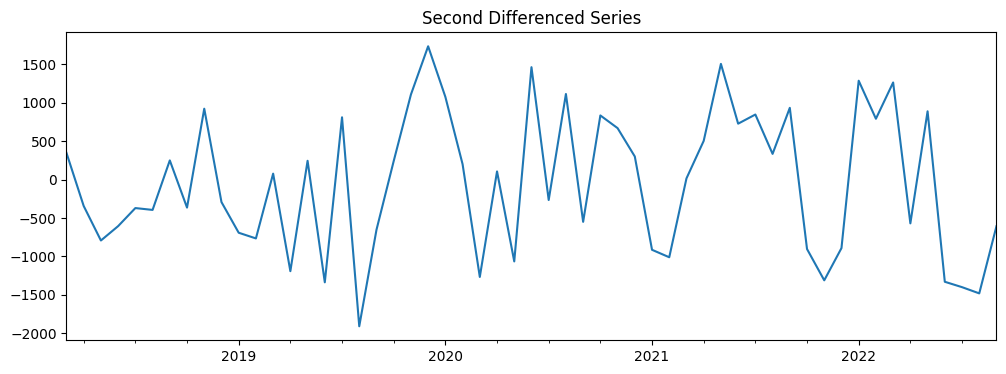

In [29]:
ts_diff = ts.diff().diff().dropna()

ts_diff.plot(figsize=(12,4))

plt.title("Second Differenced Series")

plt.show()

In [30]:
get_adfuller_results(ts_diff, label="Differenced Data")

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
Differenced Data,-5.461615,2,52,0.000003,0.05,True


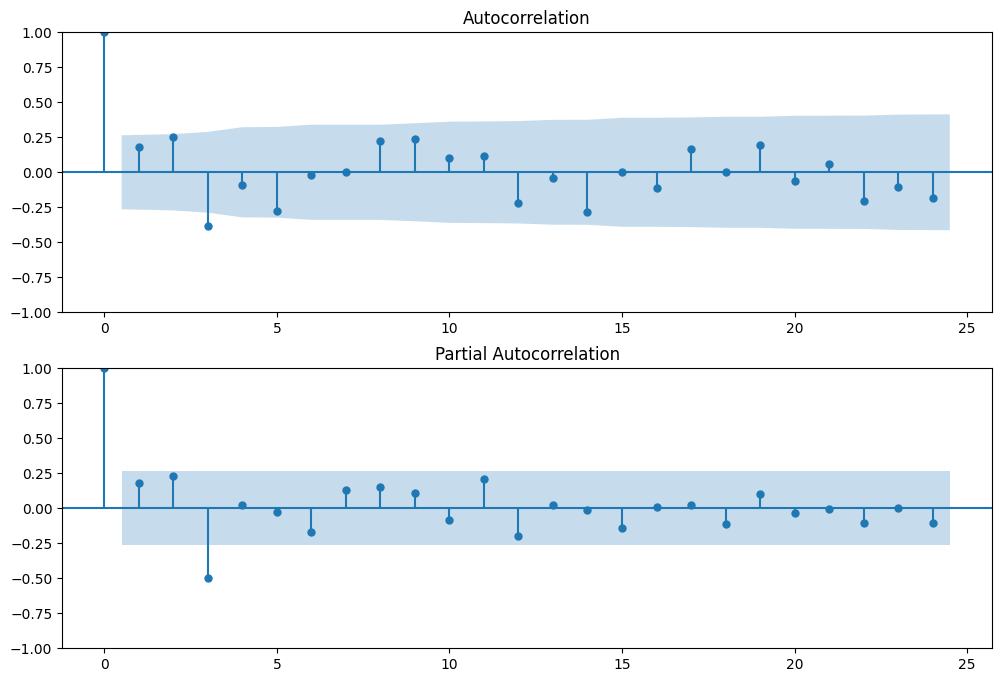

In [31]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2,1, figsize=(12,8))

plot_acf(ts_diff, lags=24, ax=ax[0])

plot_pacf(ts_diff, lags=24, ax=ax[1])

plt.show()

In [32]:
train, test = train_test_split(ts, test_size=6)

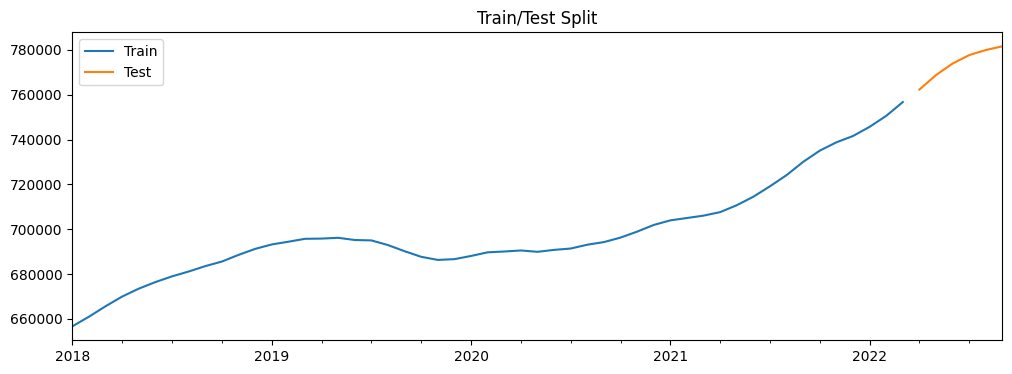

In [33]:
ax = train.plot(label="Train")
test.plot(ax=ax, label="Test")
plt.title("Train/Test Split")
plt.legend()
plt.show()

In [34]:
manual_model = tsa.ARIMA(
    train,
    order=(3, 2, 0)
).fit()

manual_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Home Value   No. Observations:                   51
Model:                 ARIMA(3, 2, 0)   Log Likelihood                -403.367
Date:                Sat, 11 Jul 2026   AIC                            814.734
Time:                        13:15:13   BIC                            822.302
Sample:                    01-31-2018   HQIC                           817.605
                         - 03-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0004      0.070     -0.006      0.995      -0.139       0.138
ar.L2          0.0036      0.046      0.078      0.938      -0.086       0.093
ar.L3          0.0039      0.042      0.092      0.927      -0.079       0.087
sigma2      5.506e+05    1.1e+05      4.989      0.000    3.34e+05    7.67e+05
===================================================================================
Ljung-Box (L1) (Q):                   1.02   Jarque-Bera (JB):                 1.65
Prob(Q):                              0.31   Prob(JB):                         0.44
Heteroskedasticity (H):               2.29   Skew:                            -0.08
Prob(H) (two-sided):                  0.11   Kurtosis:                         2.12
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
manual_forecast_df = manual_model.get_forecast(
    steps=len(test)
).summary_frame()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Manual ARIMA(3,2,0) Forecast vs Test'}>)

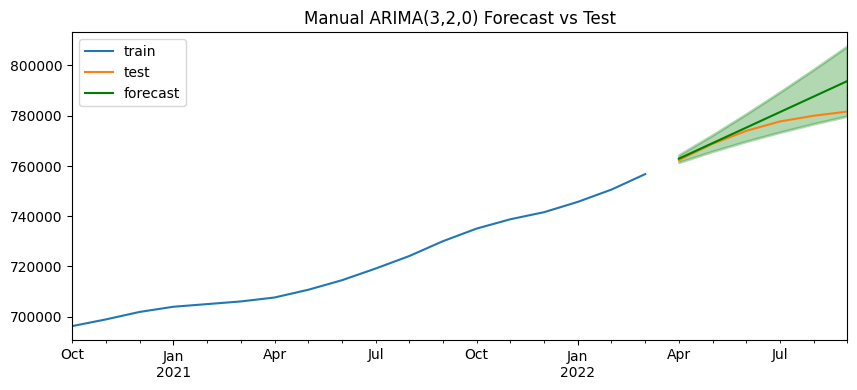

In [36]:
plot_forecast(
    train,
    test,
    manual_forecast_df,
    n_train_lags=18,
    title="Manual ARIMA(3,2,0) Forecast vs Test"
)

In [49]:
manual_metrics = regression_metrics_ts(
    test,
    manual_forecast_df["mean"],
    label="Manual ARIMA(3,2,0)",
    output_dict=True
)

------------------------------------------------------------
Regression Metrics: Manual ARIMA(3,2,0)
------------------------------------------------------------
- MAE = 4,276.720
- MSE = 36,984,363.458
- RMSE = 6,081.477
- R^2 = 0.180
- MAPE = 0.55%


In [50]:
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    d=d,
    D=D,

    start_p=0,
    start_q=0,

    max_p=5,
    max_q=5,

    start_P=0,
    start_Q=0,

    max_P=2,
    max_Q=2,

    trace=True,

    error_action="ignore",
    suppress_warnings=True,

    stepwise=True
)

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=806.526, Time=0.03 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=810.208, Time=0.44 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=810.215, Time=0.08 sec
 ARIMA(0,2,0)(1,0,0)[12]             : AIC=808.660, Time=0.12 sec
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=809.620, Time=0.14 sec
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=810.179, Time=4.80 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=808.395, Time=0.16 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=808.397, Time=0.04 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=809.469, Time=0.80 sec
 ARIMA(0,2,0)(0,0,0)[12] intercept   : AIC=808.438, Time=0.04 sec

Best model:  ARIMA(0,2,0)(0,0,0)[12]          
Total fit time: 6.648 seconds


In [51]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   51
Model:               SARIMAX(0, 2, 0)   Log Likelihood                -402.263
Date:                Sat, 11 Jul 2026   AIC                            806.526
Time:                        13:35:16   BIC                            808.418
Sample:                    01-31-2018   HQIC                           807.244
                         - 03-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      7.899e+05   2.22e+05      3.550      0.000    3.54e+05    1.23e+06
===================================================================================
Ljung-Box (L1) (Q):                   1.22   Jarque-Bera (JB):                 1.94
Prob(Q):                              0.27   Prob(JB):                         0.38
Heteroskedasticity (H):               1.99   Skew:                            -0.05
Prob(H) (two-sided):                  0.18   Kurtosis:                         2.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [52]:
best_model = tsa.ARIMA(
    train,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order
).fit()

In [53]:
best_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Home Value   No. Observations:                   51
Model:                 ARIMA(0, 2, 0)   Log Likelihood                -402.263
Date:                Sat, 11 Jul 2026   AIC                            806.526
Time:                        13:36:11   BIC                            808.418
Sample:                    01-31-2018   HQIC                           807.244
                         - 03-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      7.899e+05   2.22e+05      3.550      0.000    3.54e+05    1.23e+06
===================================================================================
Ljung-Box (L1) (Q):                   1.22   Jarque-Bera (JB):                 1.94
Prob(Q):                              0.27   Prob(JB):                         0.38
Heteroskedasticity (H):               1.99   Skew:                            -0.05
Prob(H) (two-sided):                  0.18   Kurtosis:                         2.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [54]:
best_forecast_df = best_model.get_forecast(
    steps=len(test)
).summary_frame()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Auto ARIMA Forecast vs Test'}>)

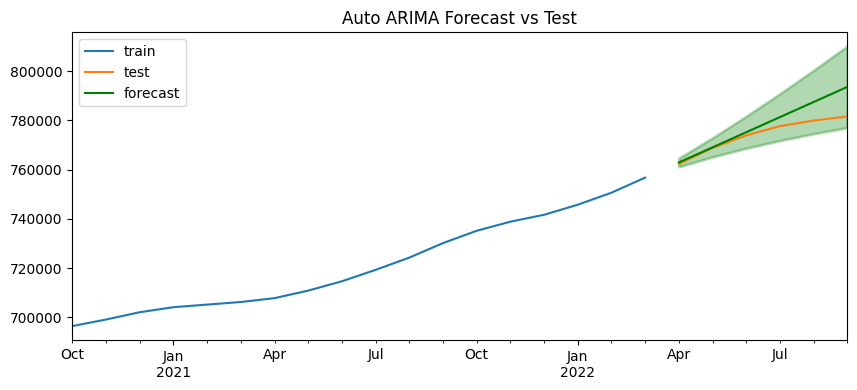

In [55]:
plot_forecast(
    train,
    test,
    best_forecast_df,
    n_train_lags=18,
    title="Auto ARIMA Forecast vs Test"
)

In [56]:
best_metrics = regression_metrics_ts(
    test,
    best_forecast_df["mean"],
    label="Auto ARIMA",
    output_dict=True
)

------------------------------------------------------------
Regression Metrics: Auto ARIMA
------------------------------------------------------------
- MAE = 4,224.000
- MSE = 36,270,850.333
- RMSE = 6,022.529
- R^2 = 0.196
- MAPE = 0.54%


In [57]:
final_model = tsa.ARIMA(
    ts,
    order=(0, 2, 0)
).fit()

In [58]:
future_forecast = final_model.get_forecast(
    steps=6
).summary_frame()

future_forecast

Home Value,mean,mean_se,mean_ci_lower,mean_ci_upper
2022-10-31,783284.0,915.565961,781489.523691,785078.476309
2022-11-30,784946.0,2047.267727,780933.428989,788958.571011
2022-12-31,786608.0,3425.734141,779893.684463,793322.315537
2023-01-31,788270.0,5014.761297,778441.248467,798098.751533
2023-02-28,789932.0,6790.018895,776623.807512,803240.192488
2023-03-31,791594.0,8733.942616,774475.787029,808712.212971


In [59]:
first_forecast = future_forecast["mean"].iloc[0]
final_forecast = future_forecast["mean"].iloc[-1]

raw_change = final_forecast - first_forecast
percent_change = (raw_change / first_forecast) * 100

print("First forecasted value:", first_forecast)
print("Final forecasted value:", final_forecast)
print("Raw change:", raw_change)
print("Percent change:", percent_change)

First forecasted value: 783284.0
Final forecasted value: 791594.0
Raw change: 8310.0
Percent change: 1.0609178790834486


## Final Forecast Summary

The final model selected was **Auto ARIMA (0,2,0)** because it achieved better performance than the manually selected model, with a lower AIC and slightly better forecasting metrics (MAPE = 0.54%).

Using the final model trained on the entire dataset, a six-month forecast was generated beyond the available data.

### Forecast Results

- **Predicted home value after 6 months:** **$791,594**
- **Starting forecasted value:** **$783,284**
- **Ending forecasted value:** **$791,594**
- **Raw increase:** **$8,310**
- **Percent increase:** **1.06%**

Overall, the model predicts a modest but steady increase in New York City home values over the next six months.